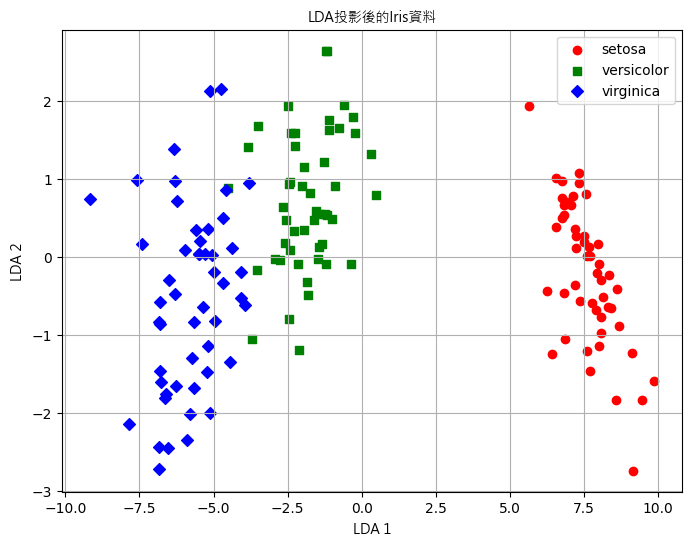

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from matplotlib.font_manager import FontProperties

%matplotlib inline
# 加載資料集 (Iris)
iris = load_iris()
X = iris.data  # 特徵
y = iris.target  # 標籤

# 進行 LDA 分析，降維到 2 維
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

# 3. 繪製圖形
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
markers = ['o', 's', 'D']
labels = iris.target_names

for i, color, marker in zip(np.unique(y), colors, markers):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1],
                color=color, marker=marker, label=labels[i])

plt.title('LDA投影後的Iris資料', fontproperties=FontProperties(fname='msjh.ttc'))
plt.xlabel('LDA 1', fontproperties=FontProperties(fname='msjh.ttc'))
plt.ylabel('LDA 2', fontproperties=FontProperties(fname='msjh.ttc'))
plt.legend()
plt.grid(True)
plt.show()


## https://www.openml.org/

In [2]:
from sklearn.datasets import fetch_openml
import plotly.express as px
# 使用 scikit-learn 從 OpenML 載入 Fashion-MNIST（取代 keras 的載入方式）
X_fashion, y_fashion = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

# 確保數值型別並標準化到 [0,1]
X_fashion = X_fashion.astype(np.float32) / 255.0
# y 可能是字串，轉為整數
y_fashion = y_fashion.astype(int)

# 為了速度可選擇抽樣（可調整 n_samples 或移除抽樣）
n_samples = 5000
if X_fashion.shape[0] > n_samples:
    rng = np.random.default_rng(0)
    idx = rng.choice(X_fashion.shape[0], n_samples, replace=False)
    X_sub, y_sub = X_fashion[idx], y_fashion[idx]
else:
    X_sub, y_sub = X_fashion, y_fashion

# 使用 LDA 將資料降到 3 維（使用已在其他 cell 匯入的 LDA）
lda_fmnist = LDA(n_components=3)
X_lda_f = lda_fmnist.fit_transform(X_sub, y_sub)

# 使用 plotly 繪製 3D 散佈圖，不同類別自動配色
fig = px.scatter_3d(
    x=X_lda_f[:, 0], y=X_lda_f[:, 1], z=X_lda_f[:, 2],
    color=y_sub.astype(str),
    labels={'color': 'class'},
    title='Fashion-MNIST LDA 3D Projection'
)
fig.update_traces(marker=dict(size=3))
fig.show()

Original features - train time: 458.6842s, pred time: 0.0063s, test acc: 0.7200
LDA(3) features  - train time: 0.0128s, pred time: 0.0003s, test acc: 0.5700


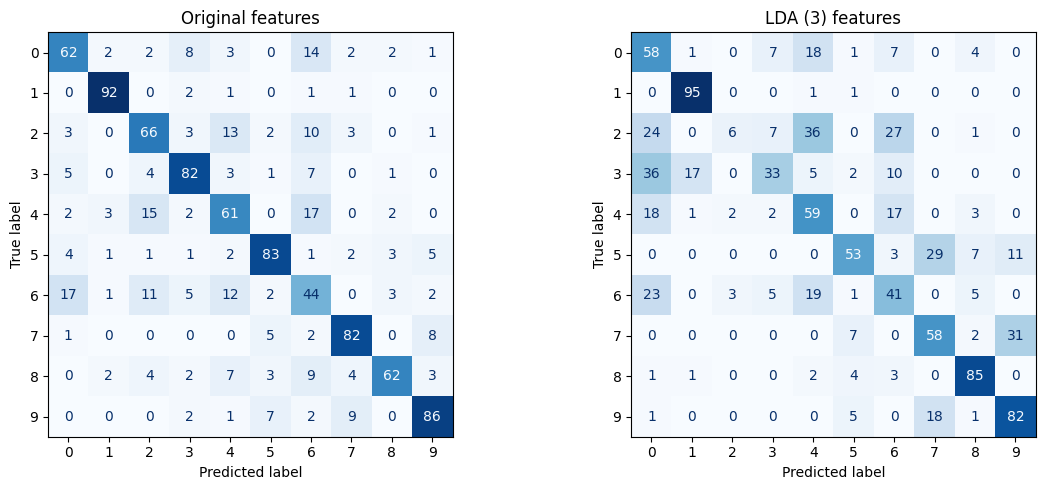

In [3]:
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 使用先前抽樣的資料 X_sub, y_sub（若尚未執行上一 cell，請先執行載入 cell）
X = X_sub
y = y_sub

# 建立一致的 train/test index（確保兩種方法使用相同切分）
idx = np.arange(X.shape[0])
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=0, stratify=y)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

results = {}

# --- 方法 1: 原始 (flattened) features + LinearSVC ---
scaler_orig = StandardScaler()
X_train_orig = scaler_orig.fit_transform(X_train)
X_test_orig = scaler_orig.transform(X_test)

clf1 = LinearSVC(max_iter=10000, dual=False, random_state=0)
t0 = time.perf_counter()
clf1.fit(X_train_orig, y_train)
t1 = time.perf_counter()
train_time1 = t1 - t0
t0 = time.perf_counter()
y_pred1 = clf1.predict(X_test_orig)
t1 = time.perf_counter()
pred_time1 = t1 - t0
acc1 = accuracy_score(y_test, y_pred1)
cm1 = confusion_matrix(y_test, y_pred1)

results['original'] = {
    'train_time': train_time1,
    'pred_time': pred_time1,
    'accuracy': acc1,
    'confusion_matrix': cm1
}

# --- 方法 2: LDA (fit on train only) -> 3D + LinearSVC ---
n_components = min(3, len(np.unique(y_train)) - 1)  # LDA 最大維度受限於類別數量
lda2 = LDA(n_components=n_components)
X_train_lda = lda2.fit_transform(X_train, y_train)
X_test_lda = lda2.transform(X_test)

scaler_lda = StandardScaler()
X_train_lda_s = scaler_lda.fit_transform(X_train_lda)
X_test_lda_s = scaler_lda.transform(X_test_lda)

clf2 = LinearSVC(max_iter=10000, dual=False, random_state=0)
t0 = time.perf_counter()
clf2.fit(X_train_lda_s, y_train)
t1 = time.perf_counter()
train_time2 = t1 - t0
t0 = time.perf_counter()
y_pred2 = clf2.predict(X_test_lda_s)
t1 = time.perf_counter()
pred_time2 = t1 - t0
acc2 = accuracy_score(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred2)

results['lda3d'] = {
    'train_time': train_time2,
    'pred_time': pred_time2,
    'accuracy': acc2,
    'confusion_matrix': cm2
}

# 列印比較結果
print(f'Original features - train time: {train_time1:.4f}s, pred time: {pred_time1:.4f}s, test acc: {acc1:.4f}')
print(f'LDA({n_components}) features  - train time: {train_time2:.4f}s, pred time: {pred_time2:.4f}s, test acc: {acc2:.4f}')

# 顯示 confusion matrices (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Original features')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'LDA ({n_components}) features')
plt.tight_layout()
plt.show()